In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, viridis

In [ ]:
df = pd.read_csv('/content/fc25new.csv')
df.head()

,ID,Name,Age,Positions,Nationality,Overall,Potential,Club,Height,Weight,...,GK Kicking,GK Positioning,GK Reflexes,Total stats,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Physical / Positioning
0,231866,Rodrigo Hernández Cascante,28,"CDM, CM",Spain,91,91,Manchester City,190,82,...,7.0,14,8,2306,66,80,86,84,87,85
1,209331,Mohamed Salah,32,"RM, RW",Egypt,91,91,Liverpool,175,72,...,9.0,11,14,2261,89,89,86,90,45,76
2,252371,Jude Bellingham,21,"CAM, CM",England,90,94,Real Madrid,186,75,...,10.0,5,8,2351,80,86,83,88,78,85
3,239085,Erling Haaland,23,ST,Norway,90,92,Manchester City,195,94,...,13.0,11,7,2178,88,92,70,81,45,88
4,238794,Vinícius José de Oliveira Júnior,23,"LW, ST",Brazil,90,94,Real Madrid,176,73,...,7.0,7,10,2059,95,85,81,91,29,69


In [ ]:
print(df.describe())

                  ID           Age       Overall     Potential        Height  \
count   17641.000000  17641.000000  17641.000000  17641.000000  17641.000000   
mean   217111.263817     24.945865     66.284621     71.304971    182.006519   
std     65598.662077      4.742886      6.390965      6.143490      6.858285   
min     18115.000000     16.000000     53.000000     51.000000    156.000000   
25%    210140.000000     21.000000     62.000000     67.000000    177.000000   
50%    239763.000000     24.000000     66.000000     71.000000    182.000000   
75%    260842.000000     28.000000     70.000000     75.000000    187.000000   
max    280200.000000     42.000000     91.000000     96.000000    210.000000   

             Weight         Value           Wage  Total attacking  \
count  17641.000000  1.764100e+04   17641.000000     17641.000000   
mean      75.275721  3.003769e+06   13810.540786       251.798254   
std        6.898350  7.856013e+06   19871.781906        74.081720   
min

In [ ]:
print(df.value_counts())

ID      Name                           Age  Positions   Nationality  Overall  Potential  Club                  Height  Weight  Value       Wage     Total attacking  Crossing  Finishing  Heading accuracy  Short passing  Volleys  Total skill  Dribbling  Curve  FK Accuracy  Long passing  Ball control  Total movement  Acceleration  Sprint speed  Agility  Reactions  Balance  Total power  Shot power  Jumping  Stamina  Strength  Long shots  Total mentality  Aggression  Interceptions  Att. Position  Vision  Penalties  Composure  Total defending  Defensive awareness  Standing tackle  Sliding tackle  Total goalkeeping  GK Diving  GK Handling  GK Kicking  GK Positioning  GK Reflexes  Total stats  Pace / Diving  Shooting / Handling  Passing / Kicking  Dribbling / Reflexes  Defending / Pace  Physical / Positioning
280200  Moritz Bangerter               19   CDM, CM     Germany      55       66         TSV 1860 München      192     82      250000.0    3000.0   226              49        38         4

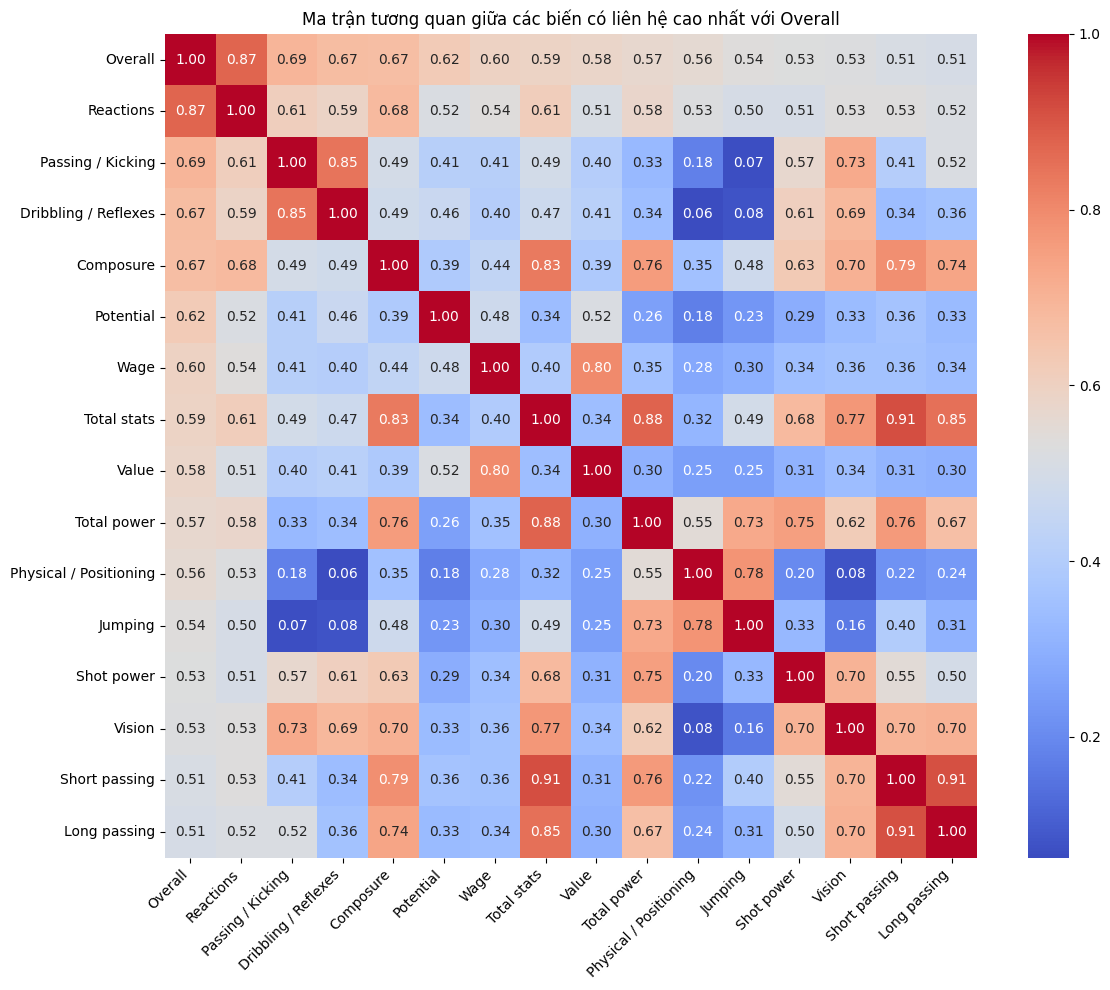

In [ ]:
# Re-import necessary libraries and reload the dataset after environment reset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Correlation with 'Overall', sorted
cor_with_overall = correlation_matrix["Overall"].sort_values(ascending=False)

# Select top 15 features (excluding 'Overall' itself)
top_corr_features = cor_with_overall.index[0:16]
top_corr_matrix = df[top_corr_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến có liên hệ cao nhất với Overall")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Chọn các cột để thống kê
df_stat = df[['Age', 'Potential', 'Value', 'Wage', 'Overall']]

# Thống kê mô tả (mean, std, min, max,...)
summary_stats = df_stat.describe()
print("📌 Thống kê mô tả:\n", summary_stats)


📌 Thống kê mô tả:
                 Age     Potential         Value           Wage       Overall
count  17641.000000  17641.000000  1.764100e+04   17641.000000  17641.000000
mean      24.945865     71.304971  3.003769e+06   13810.540786     66.284621
std        4.742886      6.143490  7.856013e+06   19871.781906      6.390965
min       16.000000     51.000000  0.000000e+00     500.000000     53.000000
25%       21.000000     67.000000  5.000000e+05    5000.000000     62.000000
50%       24.000000     71.000000  1.000000e+06    8000.000000     66.000000
75%       28.000000     75.000000  2.100000e+06   15000.000000     70.000000
max       42.000000     96.000000  1.745000e+08  440000.000000     91.000000


In [ ]:
# Tính hệ số tương quan Pearson
correlation_matrix = df_stat.corr()
print("📌 Ma trận tương quan:\n", correlation_matrix)


📌 Ma trận tương quan:
                 Age  Potential     Value      Wage   Overall
Age        1.000000  -0.346532  0.013587  0.109296  0.397378
Potential -0.346532   1.000000  0.519409  0.477546  0.623506
Value      0.013587   0.519409  1.000000  0.800889  0.582423
Wage       0.109296   0.477546  0.800889  1.000000  0.597191
Overall    0.397378   0.623506  0.582423  0.597191  1.000000


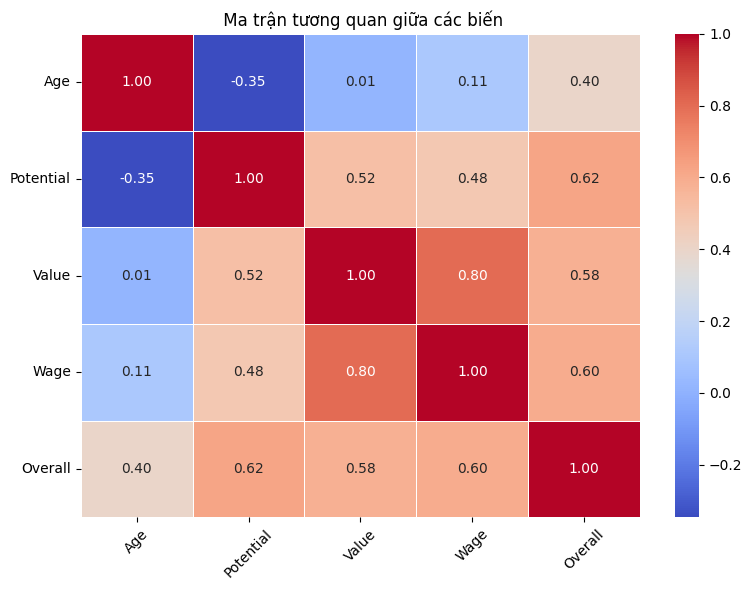

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính hệ số tương quan
correlation_matrix = df_stat.corr()

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title(" Ma trận tương quan giữa các biến")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


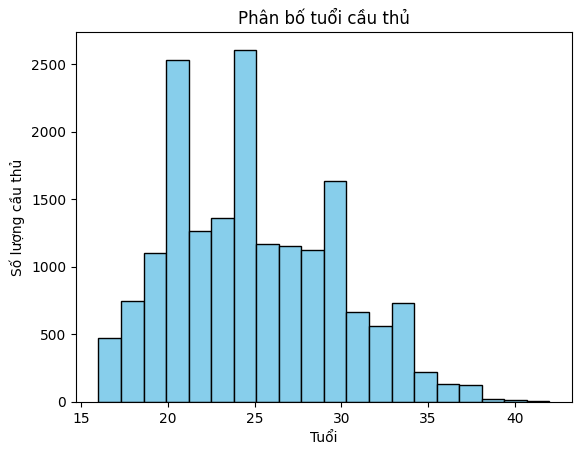

In [ ]:
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng cầu thủ')
plt.title('Phân bố tuổi cầu thủ')
plt.show()

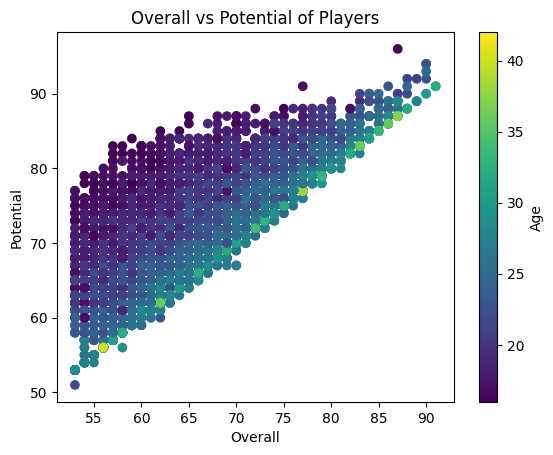

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Overall'], df['Potential'], c=df['Age'], cmap='viridis')
plt.colorbar(label='Age')
plt.xlabel('Overall')
plt.ylabel('Potential')
plt.title('Overall vs Potential of Players')
plt.show()

In [ ]:
player_ratings1 = df.groupby('Name')['Potential'].mean().reset_index()
top_pot_player = player_ratings1.sort_values(by='Potential', ascending=False).head(10)
top_pot_player

,Name,Potential
9474,Lamine Yamal,96.0
16733,Vinícius José de Oliveira Júnior,94.0
8654,Jude Bellingham,94.0
9417,Kylian Mbappé,93.0
5300,Florian Wirtz,92.0
7211,Jamal Musiala,92.0
4737,Erling Haaland,92.0
14378,Rodrygo Silva de Goes,91.0
5049,Federico Valverde,91.0
4602,Endrick Felipe Moreira de Sousa,91.0


In [ ]:
player_totalStats = df.groupby('Name')['Total stats'].mean().reset_index()
top_totalStats_player = player_totalStats.sort_values(by='Total stats', ascending=False).head(10)
top_totalStats_player

,Name,Total stats
8654,Jude Bellingham,2351.0
12723,Nicolò Barella,2334.0
6171,Hakan Çalhanoğlu,2319.0
5049,Federico Valverde,2319.0
5029,Federico Dimarco,2317.0
1450,Antoine Griezmann,2317.0
15898,Theo Hernández,2316.0
8327,Joshua Kimmich,2311.0
14347,Rodrigo Hernández Cascante,2306.0
907,Alexis Mac Allister,2300.0


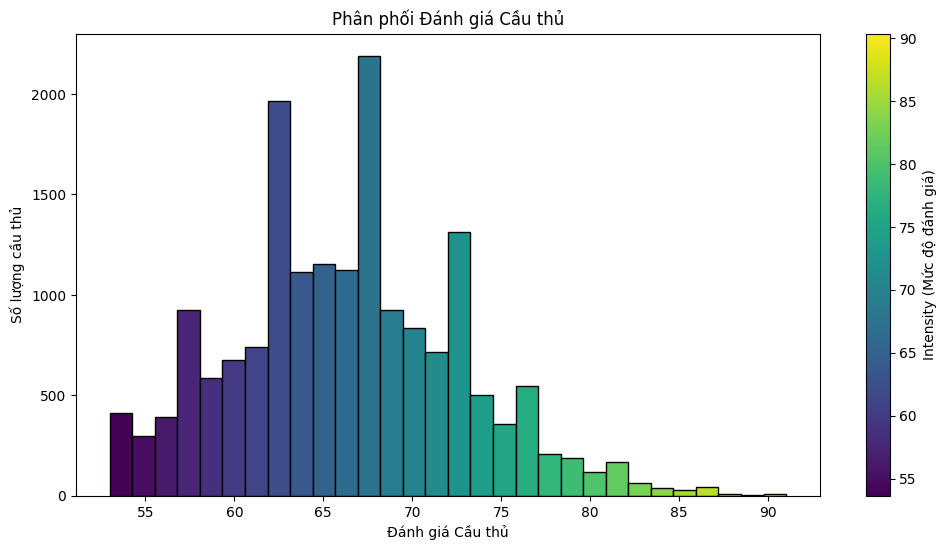

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import viridis, ScalarMappable

# Tạo figure và axes rõ ràng
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ histogram
n, bins, patches = ax.hist(df['Overall'], bins=30, edgecolor='black')

# Tính trung tâm bin và ánh xạ màu
bin_centers = 0.5 * (bins[:-1] + bins[1:])
norm = Normalize(vmin=min(bin_centers), vmax=max(bin_centers))
colors = viridis(norm(bin_centers))

# Áp dụng màu cho từng patch
for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

# Tạo colorbar gắn vào cùng figure
sm = ScalarMappable(norm=norm, cmap=viridis)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Intensity (Mức độ đánh giá)')

# Thêm tiêu đề và nhãn (Đã chuyển sang tiếng Việt)
ax.set_title('Phân phối Đánh giá Cầu thủ')
ax.set_xlabel('Đánh giá Cầu thủ')
ax.set_ylabel('Số lượng cầu thủ')

plt.show()


In [ ]:
club_ratings = df.groupby('Club')['Overall'].mean().reset_index()
top_clubs = club_ratings.sort_values(by='Overall', ascending=False).head(10)
top_clubs

,Club,Overall
327,Inter,80.840000
57,Arsenal,80.375000
370,Liverpool,79.961538
376,Manchester City,79.423077
481,Real Madrid,79.071429
59,Aston Villa,78.695652
437,Paris Saint-Germain,78.541667
412,Newcastle United,78.173913
211,FC Barcelona,78.166667
65,Atlético Madrid,77.555556


In [ ]:
club_ratings2 = df.groupby('Club')['Potential'].mean().reset_index()
top_pot_clubs = club_ratings2.sort_values(by='Potential', ascending=False).head(10)
top_pot_clubs

,Club,Potential
211,FC Barcelona,85.033333
437,Paris Saint-Germain,85.000000
481,Real Madrid,84.607143
376,Manchester City,83.846154
370,Liverpool,83.730769
57,Arsenal,83.000000
143,Chelsea,82.678571
213,FC Bayern München,82.551724
327,Inter,82.280000
94,Borussia Dortmund,82.192308


In [ ]:
national_players = df['Nationality'].value_counts().reset_index()
national_players.columns = ['Country', 'Number of Players']
top_countries = national_players.head(10)

top_countries

,Country,Number of Players
0,England,1514
1,Germany,1213
2,Spain,1047
3,Argentina,1023
4,France,871
5,Brazil,684
6,Italy,626
7,Netherlands,482
8,Norway,410
9,Sweden,405


In [ ]:
!pip install plotly


In [ ]:
import plotly.express as px
national_players = df['Nationality'].value_counts().reset_index()
national_players.columns = ['Country', 'Number of Players']

fig = px.choropleth(national_players,
                    locations='Country',
                    locationmode='country names',
                    color='Number of Players',
                    hover_name='Country',
                    color_continuous_scale='Plasma',
                    title='🌍 Số lượng cầu thủ theo quốc gia trên toàn thế giới')

fig.update_geos(showframe=False, showcoastlines=False)
fig.show()



In [ ]:
top_players = df[['Name', 'Nationality', 'Club', 'Overall']].sort_values(by='Overall', ascending=False).head(10)
top_players

,Name,Nationality,Club,Overall
0,Rodrigo Hernández Cascante,Spain,Manchester City,91
1,Mohamed Salah,Egypt,Liverpool,91
6,Virgil van Dijk,Netherlands,Liverpool,90
2,Jude Bellingham,England,Real Madrid,90
7,Harry Kane,England,FC Bayern München,90
3,Erling Haaland,Norway,Manchester City,90
5,Kylian Mbappé,France,Real Madrid,90
4,Vinícius José de Oliveira Júnior,Brazil,Real Madrid,90
12,Robert Lewandowski,Poland,FC Barcelona,89
16,Raphael Dias Belloli,Brazil,FC Barcelona,89


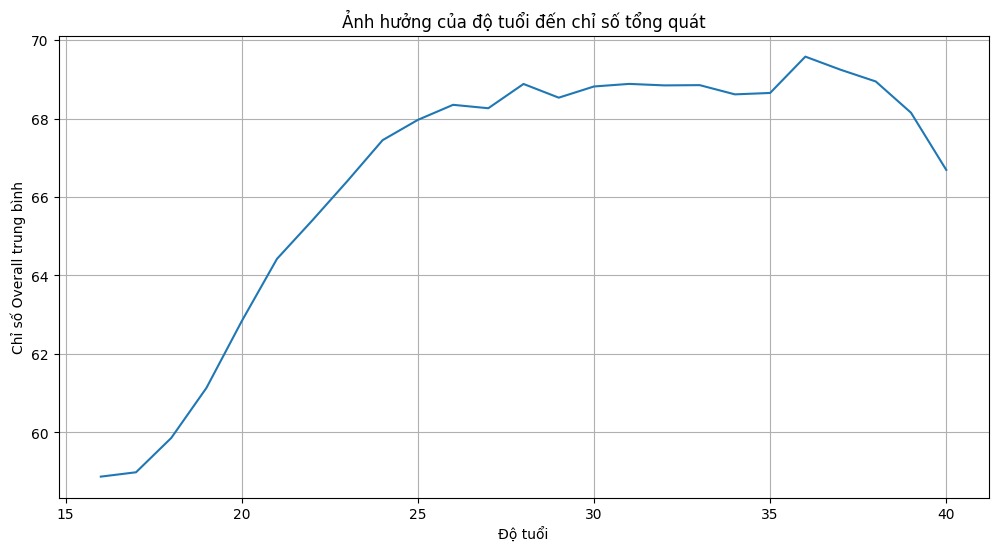

In [ ]:
filtered_dataset = df[df['Age'] < 41]

age_rating = filtered_dataset.groupby('Age')['Overall'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(age_rating['Age'], age_rating['Overall'])
plt.title('Ảnh hưởng của độ tuổi đến chỉ số tổng quát')
plt.xlabel('Độ tuổi')
plt.ylabel('Chỉ số Overall trung bình')
plt.grid(True)
plt.show()


In [ ]:
top_young_players = df[df['Age'] < 25].sort_values(by='Overall', ascending=False).head(10)

top_young_players[['Name', 'Nationality', 'Club', 'Age', 'Overall']]

,Name,Nationality,Club,Age,Overall
2,Jude Bellingham,England,Real Madrid,21,90
3,Erling Haaland,Norway,Manchester City,23,90
4,Vinícius José de Oliveira Júnior,Brazil,Real Madrid,23,90
8,Florian Wirtz,Germany,Bayer 04 Leverkusen,21,89
14,Bukayo Saka,England,Arsenal,22,88
13,Jamal Musiala,Germany,FC Bayern München,21,88
23,Pedro González López,Spain,FC Barcelona,21,87
24,William Saliba,France,Arsenal,23,87
39,Lamine Yamal,Spain,FC Barcelona,16,87
22,Cole Palmer,England,Chelsea,22,87


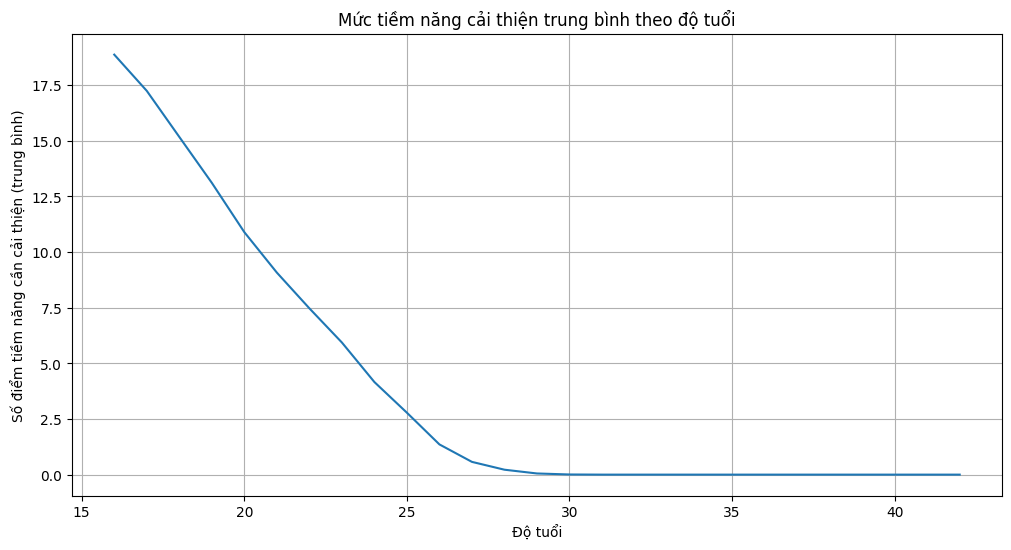

In [ ]:
df['Points to Improve'] = df['Potential'] - df['Overall']

average_improvement_by_age = df.groupby('Age')['Points to Improve'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(average_improvement_by_age['Age'], average_improvement_by_age['Points to Improve'])
plt.xlabel('Độ tuổi')
plt.ylabel('Số điểm tiềm năng cần cải thiện (trung bình)')
plt.title('Mức tiềm năng cải thiện trung bình theo độ tuổi')
plt.grid(True)
plt.show()


# Phân tích vị trí đá của cầu thủ

In [ ]:
print(df.columns.tolist())


['ID', 'Name', 'Age', 'Positions', 'Nationality', 'Overall', 'Potential', 'Club', 'Height', 'Weight', 'Value', 'Wage', 'Total attacking', 'Crossing', 'Finishing', 'Heading accuracy', 'Short passing', 'Volleys', 'Total skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long passing', 'Ball control', 'Total movement', 'Acceleration', 'Sprint speed', 'Agility', 'Reactions', 'Balance', 'Total power', 'Shot power', 'Jumping', 'Stamina', 'Strength', 'Long shots', 'Total mentality', 'Aggression', 'Interceptions', 'Att. Position', 'Vision', 'Penalties', 'Composure', 'Total defending', 'Defensive awareness', 'Standing tackle', 'Sliding tackle', 'Total goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total stats', 'Pace / Diving', 'Shooting / Handling', 'Passing / Kicking', 'Dribbling / Reflexes', 'Defending / Pace', 'Physical / Positioning', 'Points to Improve']


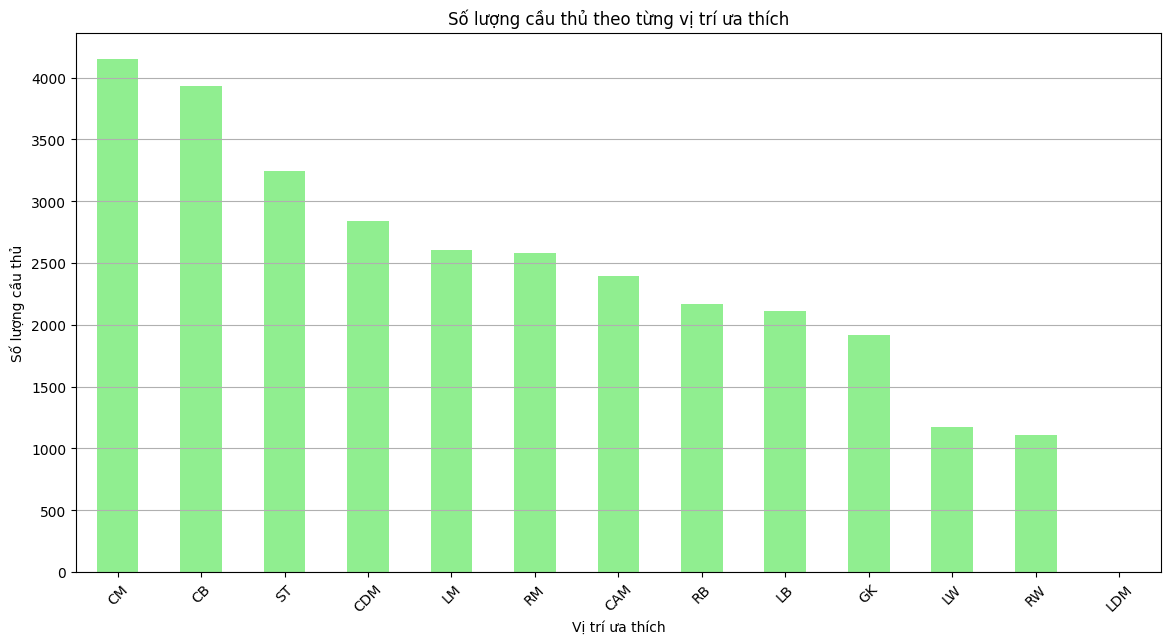

In [ ]:
# Làm sạch các vị trí
preferred_positions = (
    df['Positions']
    .str.replace(r'[^\w\s]', '', regex=True)  # bỏ dấu chấm, phẩy, nháy đơn,...
    .str.upper()  # chuyển về chữ in hoa đồng bộ
    .str.split()
    .explode()
    .value_counts()
)

# Vẽ lại biểu đồ
plt.figure(figsize=(14, 7))
preferred_positions.plot(kind='bar', color='lightgreen')
plt.xlabel('Vị trí ưa thích')
plt.ylabel('Số lượng cầu thủ')
plt.title('Số lượng cầu thủ theo từng vị trí ưa thích')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [ ]:
# Tìm các vị trí có chứa "LDM"
df[df['Positions'].str.contains('LDM', na=False)]


,ID,Name,Age,Positions,Nationality,Overall,Potential,Club,Height,Weight,...,GK Positioning,GK Reflexes,Total stats,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Physical / Positioning,Points to Improve
2118,208054,Leandro Fernández,33,"ST, LDM, LW",Argentina,74,74,Universidad de Chile,176,74,...,12,6,1938,77,76,69,74,42,70,0


In [ ]:
df_cleaned = df.copy()
df_cleaned['Positions'] = df_cleaned['Positions'].str.replace(',', '').str.strip()

preferred_positions = df_cleaned['Positions'].str.split().explode()

df_expanded = df_cleaned.loc[preferred_positions.index].copy()
df_expanded['Positions'] = preferred_positions.values

position_overall_points = df_expanded.groupby('Positions')['Overall'].sum().reset_index()


# Lấy top 10
top_10_positions = position_overall_points.sort_values(by='Overall', ascending=False).head(10)
print(top_10_positions)


   Positions  Overall
3         CM   277456
1         CB   261213
12        ST   215722
2        CDM   191090
7         LM   174287
10        RM   172116
0        CAM   161488
9         RB   143239
5         LB   139635
4         GK   125082


In [ ]:
cb_players = df_expanded[df_expanded['Positions'] == 'CB']

top_10_cb = cb_players[['Name', 'Club', 'Overall', 'Wage']].sort_values(by='Overall', ascending=False).head(10)
top_10_cb

,Name,Club,Overall,Wage
6,Virgil van Dijk,Liverpool,90,220000.0
19,Antonio Rüdiger,Real Madrid,88,310000.0
27,Gabriel dos S. Magalhães,Arsenal,87,195000.0
34,Jonathan Tah,Bayer 04 Leverkusen,87,140000.0
24,William Saliba,Arsenal,87,170000.0
35,Marcos Aoás Corrêa,Paris Saint-Germain,87,145000.0
25,Alessandro Bastoni,Inter,87,140000.0
43,Jules Koundé,FC Barcelona,86,170000.0
45,Rúben Santos Gato Alves Dias,Manchester City,86,195000.0
46,Gleison Bremer Silva Nascimento,Juventus,86,175000.0


In [ ]:
cm_players = df_expanded[df_expanded['Positions'] == 'CM']

top_10_cm = cm_players[['Name', 'Club', 'Overall', 'Wage']].sort_values(by='Overall', ascending=False).head(10)
top_10_cm

,Name,Club,Overall,Wage
0,Rodrigo Hernández Cascante,Manchester City,91,440000.0
2,Jude Bellingham,Real Madrid,90,280000.0
10,Kevin De Bruyne,Manchester City,89,270000.0
15,Federico Valverde,Real Madrid,88,300000.0
13,Jamal Musiala,FC Bayern München,88,95000.0
31,Nicolò Barella,Inter,87,155000.0
26,Declan Rice,Arsenal,87,190000.0
23,Pedro González López,FC Barcelona,87,150000.0
32,Martin Ødegaard,Arsenal,86,195000.0
44,Alexis Mac Allister,Liverpool,86,150000.0


In [ ]:
st_players = df_expanded[df_expanded['Positions'] == 'ST']

top_10_st = st_players[['Name', 'Club', 'Overall', 'Wage']].sort_values(by='Overall', ascending=False).head(10)
top_10_st

,Name,Club,Overall,Wage
3,Erling Haaland,Manchester City,90,270000.0
4,Vinícius José de Oliveira Júnior,Real Madrid,90,340000.0
7,Harry Kane,FC Bayern München,90,170000.0
5,Kylian Mbappé,Real Madrid,90,380000.0
12,Robert Lewandowski,FC Barcelona,89,210000.0
8,Florian Wirtz,Bayer 04 Leverkusen,89,125000.0
17,Lautaro Martínez,Inter,88,185000.0
29,Ousmane Dembélé,Paris Saint-Germain,87,155000.0
36,Antoine Griezmann,Atlético Madrid,87,135000.0
28,Victor Osimhen,Galatasaray SK,87,195000.0


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Check the updated available columns
available_columns = df.columns
available_columns

Index(['id', 'name', 'age', 'positions', 'nationality', 'overall', 'potential',
       'club', 'height', 'weight', 'value', 'wage', 'total_attacking',
       'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'total_skill', 'dribbling', 'curve', 'fk_accuracy', 'long_passing',
       'ball_control', 'total_movement', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'total_power', 'shot_power',
       'jumping', 'stamina', 'strength', 'long_shots', 'total_mentality',
       'aggression', 'interceptions', 'att._position', 'vision', 'penalties',
       'composure', 'total_defending', 'defensive_awareness',
       'standing_tackle', 'sliding_tackle', 'total_goalkeeping', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes',
       'total_stats', 'pace_/_diving', 'shooting_/_handling',
       'passing_/_kicking', 'dribbling_/_reflexes', 'defending_/_pace',
       'physical_/_positioning', 'points_to_improve'],


# MESSI VS RONALDO

In [ ]:
print(df[df['name'].str.contains('Messi', case=False, na=False)]['name'])
print(df[df['name'].str.contains('Ronaldo', case=False, na=False)]['name'])


38              Lionel Messi
1475          Junior Messias
10597    Raphaël Messi Bouli
15363           Rayane Messi
Name: name, dtype: object
90         C. Ronaldo dos Santos Aveiro
153       Ronaldo Jailson Cabrais Petri
570      Ronaldo Diego Essler Domingues
4868      Fábio Ronaldo Costa Conceição
6989         Ronaldo Augusto Vieira Nan
8448                   Ronaldo Martínez
10023                   Ronaldo Dejesús
Name: name, dtype: object


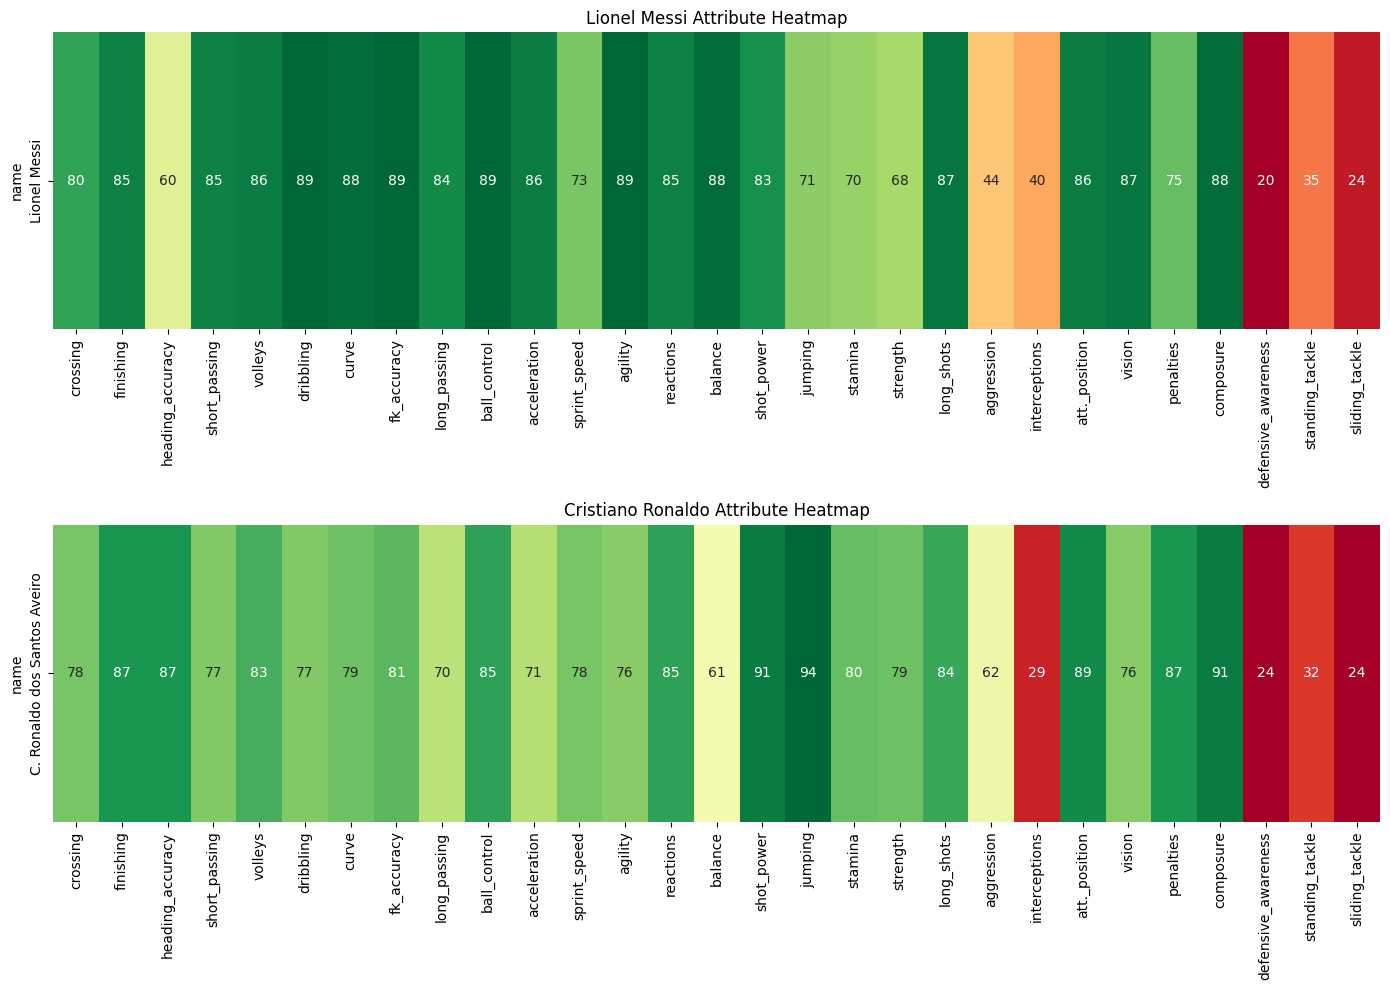

In [ ]:
# Danh sách các thuộc tính cần dùng (bỏ 'free_kick_accuracy', 'positioning', 'marking' vì tên không đúng)
attributes = ['crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
              'dribbling', 'curve', 'fk_accuracy', 'long_passing', 'ball_control',
              'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance',
              'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
              'aggression', 'interceptions', 'att._position', 'vision', 'penalties',
              'composure', 'defensive_awareness', 'standing_tackle', 'sliding_tackle']

# Lấy dữ liệu của Messi và Ronaldo
messi_ronaldo_attributes = df[df['name'].isin(['Lionel Messi', 'C. Ronaldo dos Santos Aveiro'])][['name'] + attributes]

# Đặt lại chỉ số index là 'name'
messi_ronaldo_attributes.set_index('name', inplace=True)

# Chuyển đổi dữ liệu sang số (trong trường hợp bị lỗi kiểu dữ liệu)
for attribute in attributes:
    messi_ronaldo_attributes[attribute] = pd.to_numeric(messi_ronaldo_attributes[attribute], errors='coerce')

# Vẽ biểu đồ heatmap
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

sns.heatmap(messi_ronaldo_attributes.loc[['Lionel Messi']], annot=True, cmap='RdYlGn', cbar=False, ax=ax[0])
ax[0].set_title('Lionel Messi Attribute Heatmap')

sns.heatmap(messi_ronaldo_attributes.loc[['C. Ronaldo dos Santos Aveiro']], annot=True, cmap='RdYlGn', cbar=False, ax=ax[1])
ax[1].set_title('Cristiano Ronaldo Attribute Heatmap')

plt.tight_layout()
plt.show()


Messi có thể chơi các vị trí: ['RW', 'ST', 'CAM']


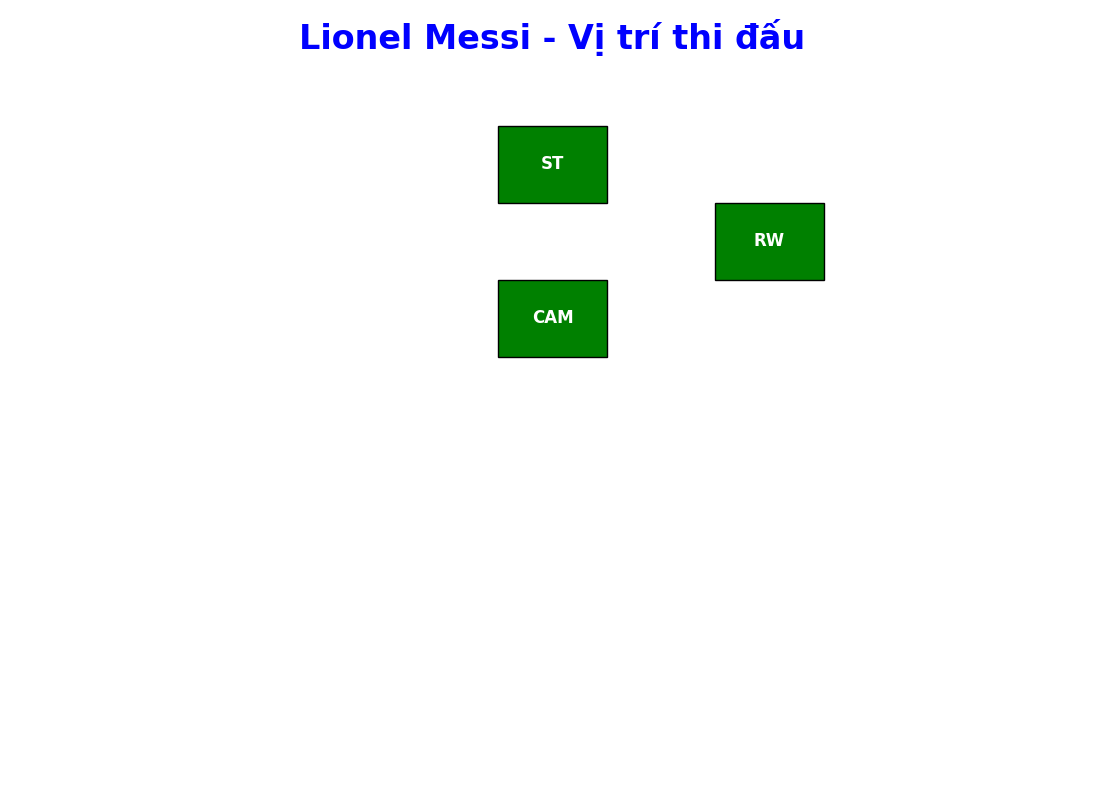

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Lấy vị trí Messi chơi được từ cột 'positions'
messi_data = df[df['name'] == 'Lionel Messi']
positions = messi_data['positions'].values[0].split(', ')

# In ra các vị trí Messi có thể chơi
print("Messi có thể chơi các vị trí:", positions)

# Sơ đồ sân bóng đơn giản
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
plt.text(5, 9.5, 'Lionel Messi - Vị trí thi đấu', fontsize=24, weight='bold', color='blue', ha='center')

# Tọa độ cho các vị trí phổ biến
position_coords = {
    'ST': (5, 8), 'CF': (5, 7),
    'LW': (3, 7), 'RW': (7, 7),
    'CAM': (5, 6), 'CM': (5, 5), 'CDM': (5, 4),
    'LM': (3, 5), 'RM': (7, 5),
    'LB': (2, 3), 'RB': (8, 3), 'CB': (5, 3),
    'LWB': (2, 4), 'RWB': (8, 4),
    'GK': (5, 1)
}

# Vẽ các vị trí Messi có thể chơi
for pos in positions:
    pos = pos.upper()
    if pos in position_coords:
        x, y = position_coords[pos]
        rect = patches.Rectangle((x-0.5, y-0.5), 1, 1, linewidth=1, edgecolor='black', facecolor='green')
        ax.add_patch(rect)
        plt.text(x, y, pos, color='white', weight='bold', ha='center', va='center', fontsize=12)
    else:
        print(f"⚠️ Không xác định được vị trí: {pos}")

plt.show()


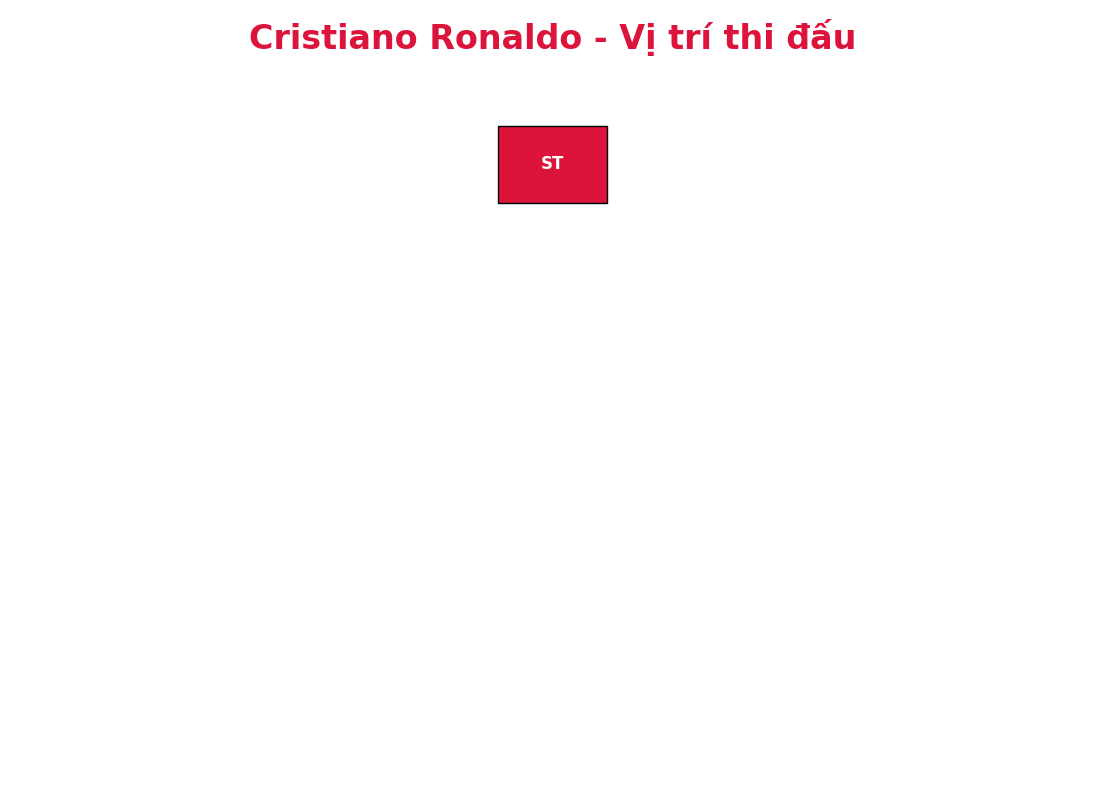

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Lấy thông tin Ronaldo
cr7_data = df[df['name'] == 'C. Ronaldo dos Santos Aveiro']
positions = cr7_data['positions'].values[0].split(', ')

# Sơ đồ sân bóng đơn giản
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Tiêu đề
plt.text(5, 9.5, 'Cristiano Ronaldo - Vị trí thi đấu', fontsize=24, weight='bold', color='crimson', ha='center')

# Tọa độ cho các vị trí phổ biến
position_coords = {
    'ST': (5, 8), 'CF': (5, 7),
    'LW': (3, 7), 'RW': (7, 7),
    'CAM': (5, 6), 'CM': (5, 5), 'CDM': (5, 4),
    'LM': (3, 5), 'RM': (7, 5),
    'LB': (2, 3), 'RB': (8, 3), 'CB': (5, 3),
    'LWB': (2, 4), 'RWB': (8, 4),
    'GK': (5, 1)
}

# Vẽ các vị trí Ronaldo có thể chơi
for pos in positions:
    pos = pos.upper()
    if pos in position_coords:
        x, y = position_coords[pos]
        rect = patches.Rectangle((x-0.5, y-0.5), 1, 1, linewidth=1, edgecolor='black', facecolor='crimson')
        ax.add_patch(rect)
        plt.text(x, y, pos, color='white', weight='bold', ha='center', va='center', fontsize=12)
    else:
        print(f"⚠️ Không xác định được vị trí: {pos}")

plt.show()


# PHÂN TÍCH CÁC CẦU THỦ TIỀN ĐẠO

/tmp/ipython-input-40-3256571641.py:13: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



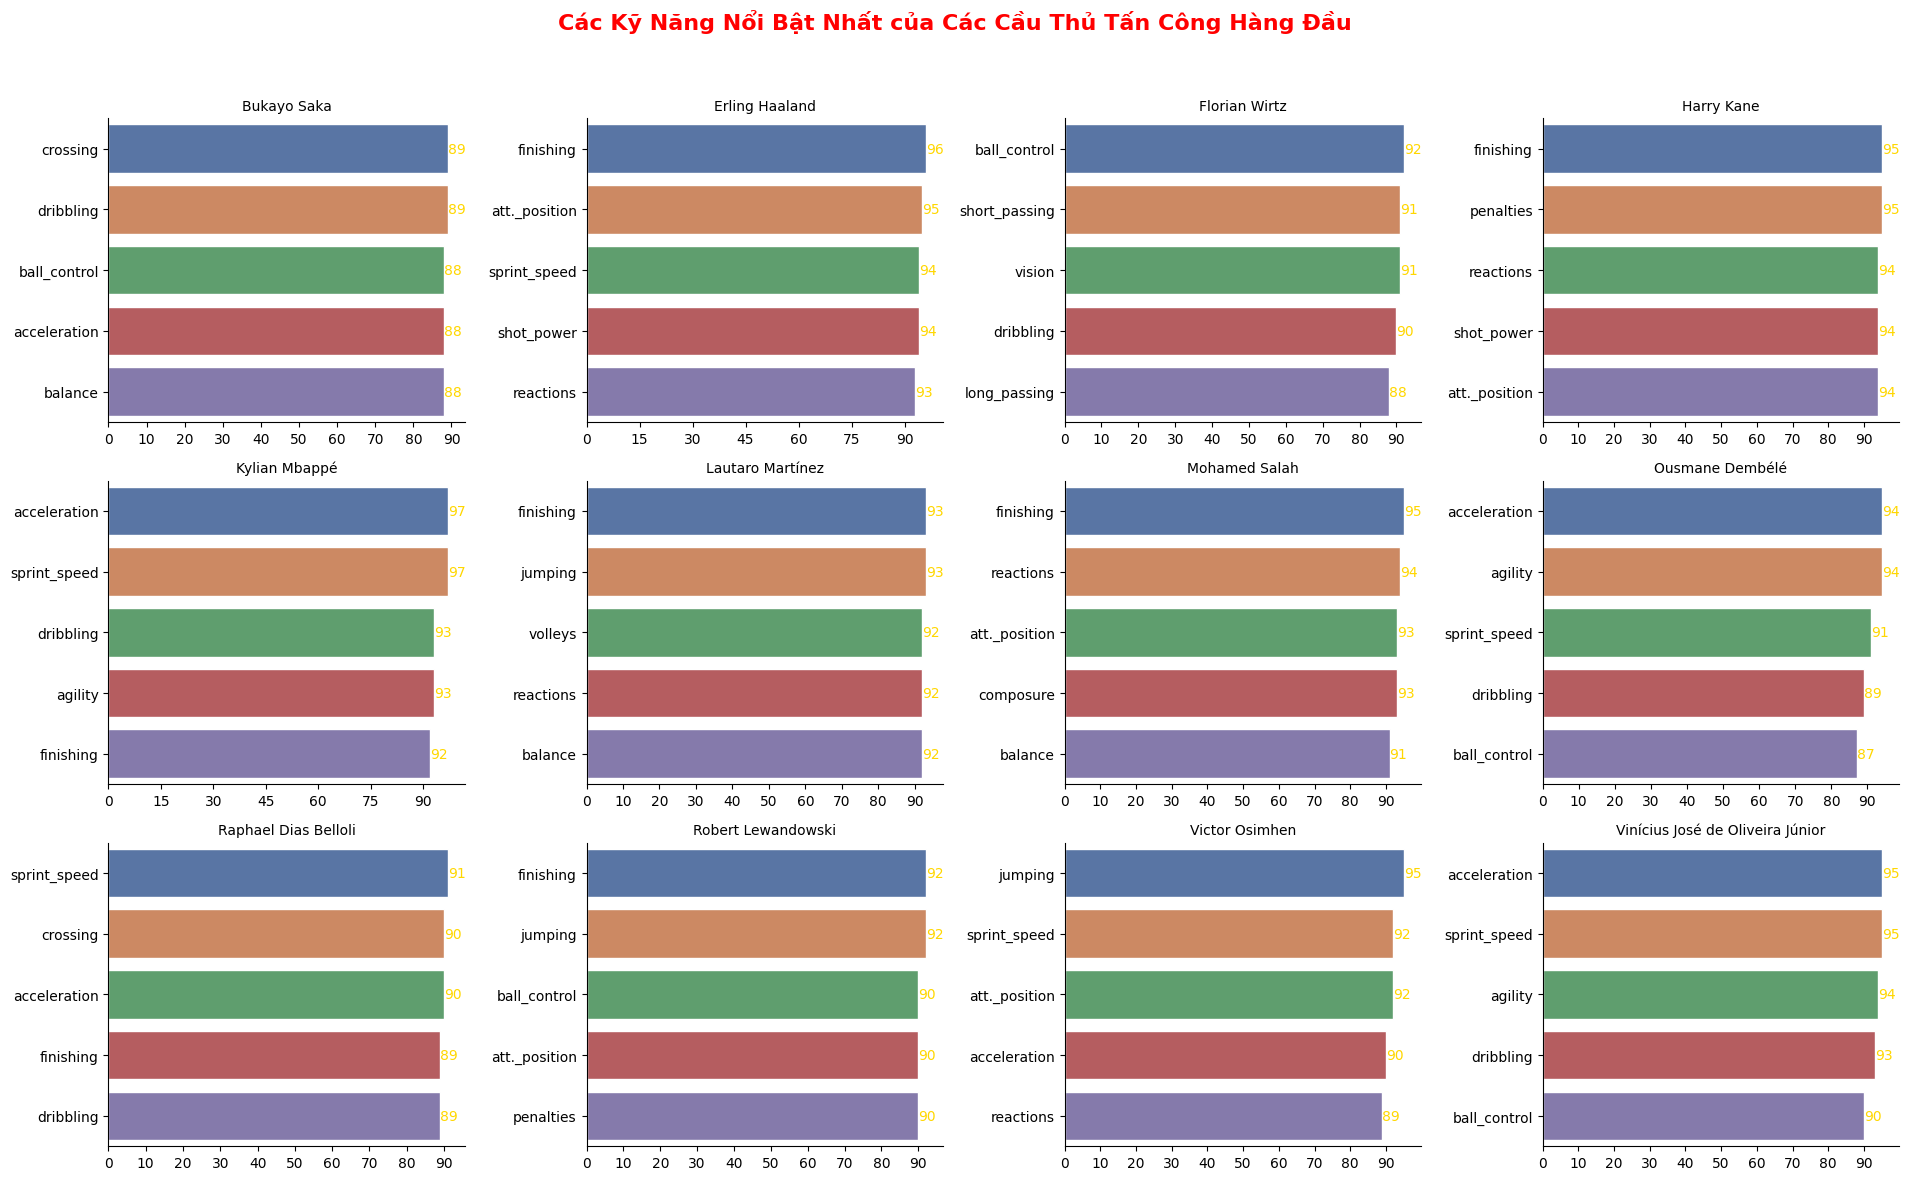

In [ ]:
# Lọc các cầu thủ tấn công
forward_positions = ['ST', 'LW', 'RW', 'CF']
forwards = df[df['positions'].str.contains('|'.join(forward_positions))]

# Chọn top 12 cầu thủ
top_forwards = forwards.nlargest(12, 'overall')

# Chuyển định dạng dữ liệu
melted_top_forwards = top_forwards.melt(id_vars=['name'], value_vars=attributes, var_name='variables', value_name='Exp')
melted_top_forwards['Exp'] = pd.to_numeric(melted_top_forwards['Exp'], errors='coerce')

# Chọn top 5 kỹ năng mỗi cầu thủ
top_attributes = melted_top_forwards.groupby('name', group_keys=False).apply(lambda x: x.nlargest(5, 'Exp')).reset_index(drop=True)

from matplotlib.ticker import MaxNLocator
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ biểu đồ
g = sns.FacetGrid(top_attributes, col='name', col_wrap=4, height=4, aspect=1.2, sharex=False, sharey=False)
g.map_dataframe(sns.barplot, y='variables', x='Exp', hue='variables', palette='deep', edgecolor='w', legend=False)

# Thêm thông tin phụ
for ax, (name, subdf) in zip(g.axes.flat, top_attributes.groupby('name')):
    for i, (var, exp) in enumerate(subdf[['variables', 'Exp']].values):
        ax.text(exp, i, f'{exp:.0f}', ha='left', va='center', color='gold')
    ax.set_title(name, color='black', fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

g.set_titles('{col_name}')
g.fig.suptitle('Các Kỹ Năng Nổi Bật Nhất của Các Cầu Thủ Tấn Công Hàng Đầu', fontsize=16, weight='bold', color='red')
g.fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


biểu đồ trên cho thấy 12 cầu thủ tấn công xuất sắc nhất trong trò chơi với 5
thuộc tính hàng đầu của họ

In [ ]:
df[df['name'].str.contains('Lionel Messi', case=False)]


,id,name,age,positions,nationality,overall,potential,club,height,weight,...,gk_positioning,gk_reflexes,total_stats,pace_/_diving,shooting_/_handling,passing_/_kicking,dribbling_/_reflexes,defending_/_pace,physical_/_positioning,points_to_improve
38,158023,Lionel Messi,37,"RW, ST, CAM",Argentina,87,87,Inter Miami,169,67,...,14,8,2100,79,85,85,89,33,64,0


In [ ]:
forward_positions = ['ST', 'LW', 'RW', 'CF']
df[df['name'].str.contains('Lionel Messi', case=False)][['name', 'positions']]


,name,positions
38,Lionel Messi,"RW, ST, CAM"


In [ ]:
forward_positions = ['ST', 'LW', 'RW', 'CF']
forwards = df[df['positions'].str.contains('|'.join(forward_positions))]
numeric_forward_players = forwards.select_dtypes(exclude=['object'])

# Displaying the first few rows of the cleaned dataset
numeric_forward_players.head()

,id,age,overall,potential,height,weight,value,wage,total_attacking,crossing,...,gk_positioning,gk_reflexes,total_stats,pace_/_diving,shooting_/_handling,passing_/_kicking,dribbling_/_reflexes,defending_/_pace,physical_/_positioning,points_to_improve
1,209331,32,91,91,175,72,104000000.0,350000.0,411,86,...,11,14,2261,89,89,86,90,45,76,0
3,239085,23,90,92,195,94,157000000.0,270000.0,404,58,...,11,7,2178,88,92,70,81,45,88,2
4,238794,23,90,94,176,73,171500000.0,340000.0,376,81,...,7,10,2059,95,85,81,91,29,69,4
5,231747,25,90,93,182,75,160000000.0,380000.0,411,78,...,11,6,2193,97,89,81,92,36,77,3
7,202126,30,90,90,188,86,117500000.0,170000.0,441,80,...,14,11,2212,65,93,83,82,49,82,0


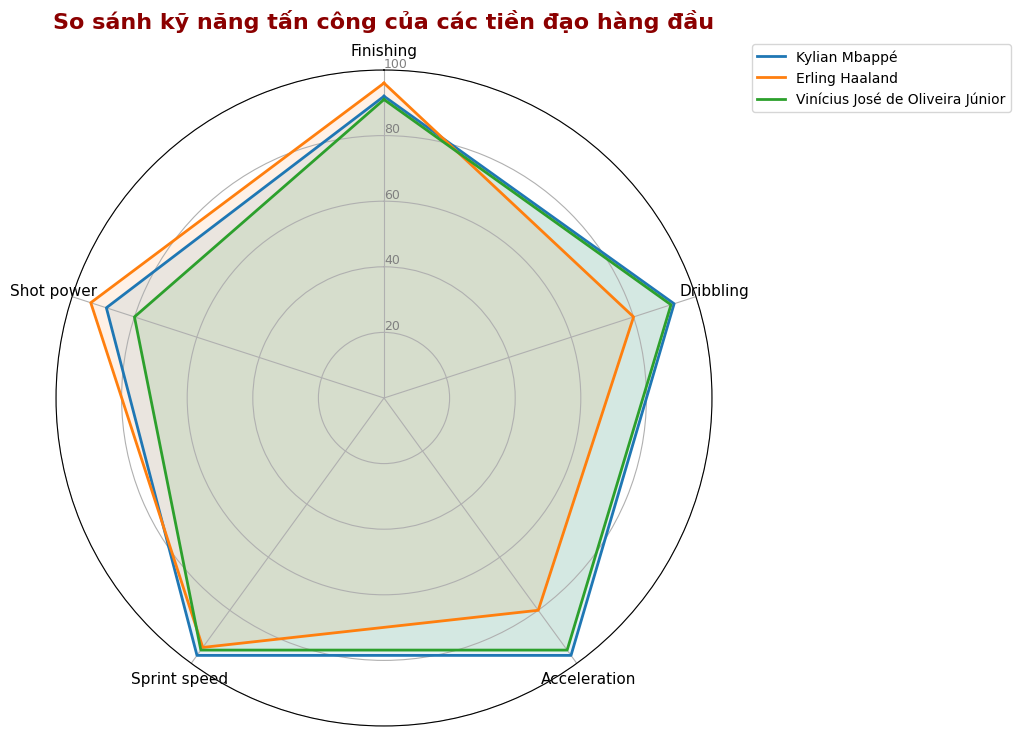

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ví dụ về dữ liệu kỹ năng của một vài cầu thủ
# Nếu bạn đã có radar_data từ trước, giữ nguyên đoạn đó
radar_data = {
    'Kylian Mbappé': [92, 93, 97, 97, 89],
    'Erling Haaland': [96, 80, 80, 94, 94],
    'Vinícius José de Oliveira Júnior': [91, 92, 95, 95, 80],
}

# Các nhãn kỹ năng
labels = ['Finishing', 'Dribbling', 'Acceleration', 'Sprint speed', 'Shot power']
num_vars = len(labels)

# Tính góc cho biểu đồ radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Khép vòng

# Tạo figure
plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# Vẽ từng cầu thủ
for player, stats in radar_data.items():
    stats += stats[:1]  # Khép vòng
    ax.plot(angles, stats, label=player, linewidth=2)
    ax.fill(angles, stats, alpha=0.1)  # Tô mờ vùng bên trong

# Cài đặt trục và nhãn
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="gray", fontsize=9)
plt.ylim(0, 100)

# Tiêu đề và legend
plt.title("So sánh kỹ năng tấn công của các tiền đạo hàng đầu",
          size=16, weight='bold', color='darkred', pad=30)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05), fontsize=10, frameon=True)
plt.tight_layout(pad=3)
plt.show()


In [ ]:
print(df.columns)


Index(['id', 'name', 'age', 'positions', 'nationality', 'overall', 'potential',
       'club', 'height', 'weight', 'value', 'wage', 'total_attacking',
       'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'total_skill', 'dribbling', 'curve', 'fk_accuracy', 'long_passing',
       'ball_control', 'total_movement', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'total_power', 'shot_power',
       'jumping', 'stamina', 'strength', 'long_shots', 'total_mentality',
       'aggression', 'interceptions', 'att._position', 'vision', 'penalties',
       'composure', 'total_defending', 'defensive_awareness',
       'standing_tackle', 'sliding_tackle', 'total_goalkeeping', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes',
       'total_stats', 'pace_/_diving', 'shooting_/_handling',
       'passing_/_kicking', 'dribbling_/_reflexes', 'defending_/_pace',
       'physical_/_positioning', 'points_to_improve'],


# MACHINE LEARNING

**chúng ta sẽ sử dụng 3 mô hình học máy khác nhau để phân tích vị trí chuyển tiếp**

Linear regression

In [ ]:
position_columns = [
    'finishing', 'heading_accuracy', 'shot_power',
    'att._position', 'volleys', 'dribbling', 'sprint_speed'
]

forward_position_data = numeric_forward_players.dropna(subset=position_columns)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X_pos = forward_position_data[position_columns]
y_pos = forward_position_data['overall']

X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(X_pos, y_pos, test_size=0.2, random_state=42)

scaler_pos = StandardScaler()
X_train_pos_scaled = scaler_pos.fit_transform(X_train_pos)
X_test_pos_scaled = scaler_pos.transform(X_test_pos)

model_pos = LinearRegression()
model_pos.fit(X_train_pos_scaled, y_train_pos)

y_pred_pos = model_pos.predict(X_test_pos_scaled)
mse_pos = mean_squared_error(y_test_pos, y_pred_pos)
r2_pos = r2_score(y_test_pos, y_pred_pos)

mse_pos, r2_pos


(2.725102193570873, 0.9363183899548729)

In [ ]:
print(numeric_forward_players.columns)


Index(['id', 'age', 'overall', 'potential', 'height', 'weight', 'value',
       'wage', 'total_attacking', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'total_skill', 'dribbling', 'curve',
       'fk_accuracy', 'long_passing', 'ball_control', 'total_movement',
       'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance',
       'total_power', 'shot_power', 'jumping', 'stamina', 'strength',
       'long_shots', 'total_mentality', 'aggression', 'interceptions',
       'att._position', 'vision', 'penalties', 'composure', 'total_defending',
       'defensive_awareness', 'standing_tackle', 'sliding_tackle',
       'total_goalkeeping', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_positioning', 'gk_reflexes', 'total_stats', 'pace_/_diving',
       'shooting_/_handling', 'passing_/_kicking', 'dribbling_/_reflexes',
       'defending_/_pace', 'physical_/_positioning', 'points_to_improve'],
      dtype='object')


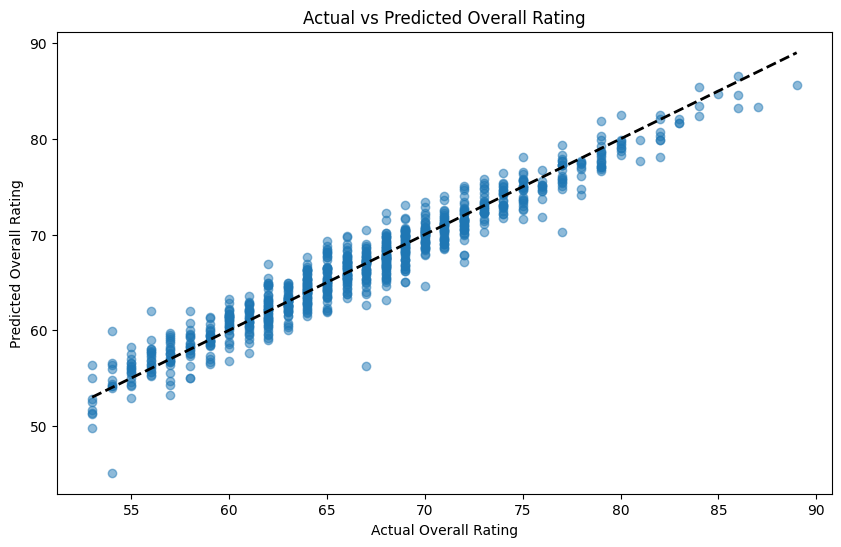

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pos, y_pred_pos, alpha=0.5)
plt.plot([y_test_pos.min(), y_test_pos.max()], [y_test_pos.min(), y_test_pos.max()], 'k--', lw=2)
plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.title('Actual vs Predicted Overall Rating')
plt.show()


random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_pos_scaled, y_train_pos)

y_pred_rf = rf_model.predict(X_test_pos_scaled)
mse_rf = mean_squared_error(y_test_pos, y_pred_rf)
r2_rf = r2_score(y_test_pos, y_pred_rf)

mse_rf, r2_rf

(2.378350386740332, 0.9444214671154731)

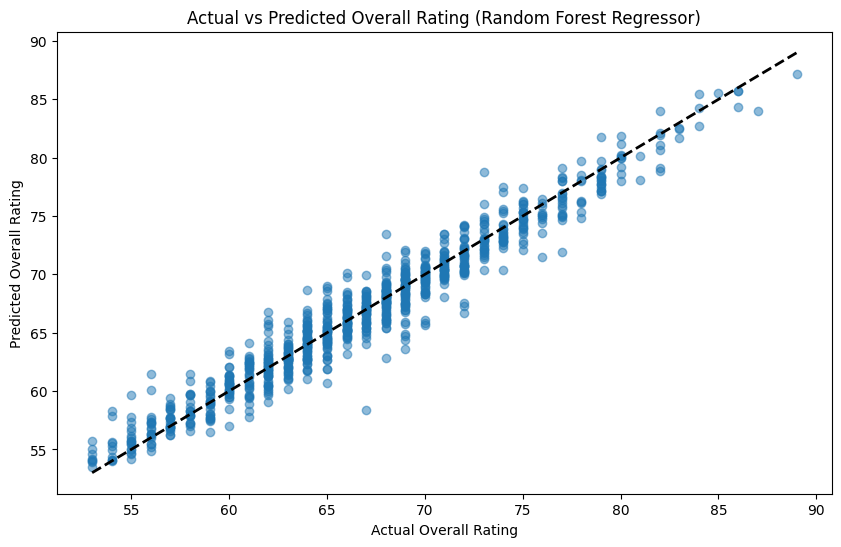

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pos, y_pred_rf, alpha=0.5)
plt.plot([y_test_pos.min(), y_test_pos.max()], [y_test_pos.min(), y_test_pos.max()], 'k--', lw=2)
plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.title('Actual vs Predicted Overall Rating (Random Forest Regressor)')
plt.show()

support vector regression

In [ ]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_pos_scaled, y_train_pos)

y_pred_svr = svr_model.predict(X_test_pos_scaled)
mse_svr = mean_squared_error(y_test_pos, y_pred_svr)
r2_svr = r2_score(y_test_pos, y_pred_svr)

mse_svr, r2_svr

(2.5482825312693262, 0.9404504040898156)

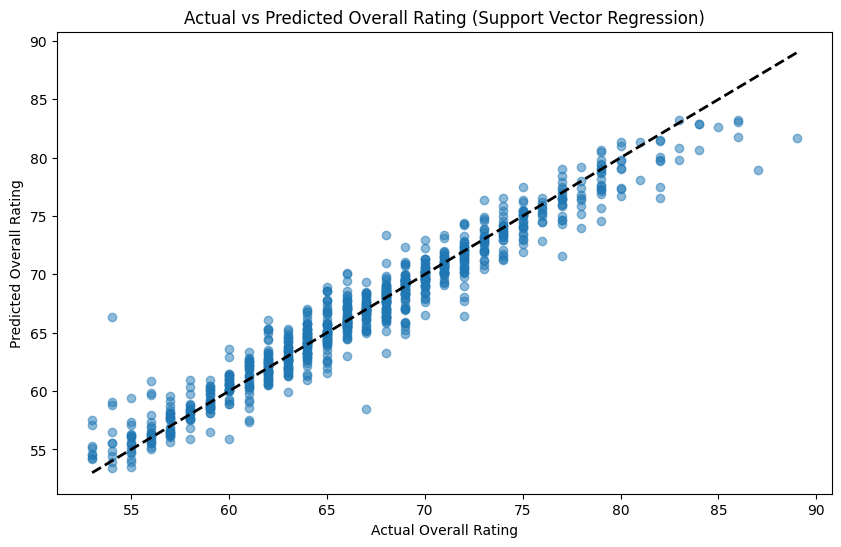

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pos, y_pred_svr, alpha=0.5)
plt.plot([y_test_pos.min(), y_test_pos.max()], [y_test_pos.min(), y_test_pos.max()], 'k--', lw=2)
plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.title('Actual vs Predicted Overall Rating (Support Vector Regression)')
plt.show()

**comparison of the 3 machine learning models**

In [ ]:
comparison = pd.DataFrame({'Model': ['Linear Regression', 'Random Forest', 'Support Vector Regression'], 'MSE': [mse_pos, mse_rf, mse_svr], 'R²': [r2_pos, r2_rf, r2_svr]})
comparison

,Model,MSE,R²
0,Linear Regression,2.725102,0.936318
1,Random Forest,2.378350,0.944421
2,Support Vector Regression,2.548283,0.940450


Sai số bình phương trung bình (MSE): Mô hình Random Forest có giá trị MSE thấp nhất, điều này cho thấy mô hình RF có độ chính xác dự đoán tốt hơn.

Hệ số xác định (R²): Mô hình Random Forest có giá trị R² cao nhất, điều này chứng tỏ mô hình RF giải thích được tỷ lệ lớn phương sai trong đánh giá tổng thể của các vị trí tiền đạo.

# **Điều này cho thấy Random Forest hoạt động hiệu quả hơn so với các mô hình khác trong tình huống này.**

In [ ]:
young_players = df[df['age'] < 20]
young_players_unique = young_players.drop_duplicates(subset=['name', 'age', 'overall', 'potential', 'nationality', 'club'])

top_young_players_unique = young_players_unique.sort_values(by='potential', ascending=False)
top_young_players_display_unique = top_young_players_unique[['name', 'age', 'overall', 'potential', 'nationality', 'club']]

top_10_young_players_unique = top_young_players_display_unique.head(10)
top_young_players_display_unique.head(10)

,name,age,overall,potential,nationality,club
39,Lamine Yamal,16,87,96,Spain,FC Barcelona
872,Endrick Felipe Moreira de Sousa,17,77,91,Brazil,Real Madrid
91,João Pedro Gonçalves Neves,19,84,90,Portugal,Paris Saint-Germain
128,Pablo Martín Páez Gavira,19,83,89,Spain,FC Barcelona
356,Désiré Doué,19,80,89,France,Paris Saint-Germain
1595,Franco Mastantuono,16,75,88,Argentina,River Plate
1152,Antonio Nusa,19,76,88,Norway,RB Leipzig
870,Jorrel Hato,18,77,88,Netherlands,Ajax
479,Arda Güler,19,80,88,Türkiye,Real Madrid
357,Warren Zaïre-Emery,18,80,88,France,Paris Saint-Germain
